# 01 - STEAM EDA (Databricks + PySpark)

**Objectif** : charger le dataset Steam (JSON imbrique), construire une table propre `games`,
normaliser les champs imbriques (genres, langues, plateformes) et produire les tables
d'agregation qui alimentent le dashboard.

Dataset : `s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json`
(55 691 jeux). Le fichier est un **tableau JSON** (`multiLine=True`), chaque element a un
champ `id` et un champ imbrique `data`.

In [1]:
# --- Bootstrap : ce notebook tourne sur Databricks ET en local ---
# Sur Databricks, `spark` et `display` existent deja. En local on les cree.
import os

try:
    spark  # fourni par Databricks
    ON_DATABRICKS = True
except NameError:
    ON_DATABRICKS = False
    from pyspark.sql import SparkSession
    spark = (
        SparkSession.builder
        .master("local[*]")
        .appName("steam_eda")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.warehouse.dir", os.environ.get("STEAM_WAREHOUSE", "spark-warehouse"))
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")

# parsing de dates tolerant (jour/mois sur 1 chiffre, valeurs invalides -> null)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

# En local, `display` (IPython) n'affiche que le schema d'un DataFrame Spark :
# on le remplace pour rendre les vraies valeurs sous forme de table pandas.
if not ON_DATABRICKS:
    import pyspark.sql
    from IPython.display import display as _ipy_display
    def display(obj, n=1000):
        if isinstance(obj, pyspark.sql.DataFrame):
            return _ipy_display(obj.limit(n).toPandas())
        return _ipy_display(obj)

from pyspark.sql import functions as F
from pyspark.sql import types as T

# Chemin des donnees : variable d'env en local, sinon fichier local, sinon S3 public Jedha
S3 = "s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json"
PATH = os.environ.get("STEAM_JSON") or ("steam_game_output.json" if os.path.exists("steam_game_output.json") else S3)
print("Lecture du dataset depuis :", PATH)


Lecture du dataset depuis : C:/tmp/steam_data/steam_game_output.json


In [2]:
raw = spark.read.option("multiLine", True).json(PATH)

print("rows =", raw.count(), "| top-level columns =", raw.columns)
raw.select("data.appid", "data.name", "data.publisher", "data.genre",
           "data.price", "data.discount", "data.release_date").show(5, truncate=40)

rows = 55691 | top-level columns = ['data', 'id']


+-------+---------------------------+------------------------+-----------------------------------+-----+--------+------------+
|  appid|                       name|               publisher|                              genre|price|discount|release_date|
+-------+---------------------------+------------------------+-----------------------------------+-----+--------+------------+
|     10|             Counter-Strike|                   Valve|                             Action|  999|       0|   2000/11/1|
|1000000|                  ASCENXION|PsychoFlux Entertainment|           Action, Adventure, Indie|  999|       0|  2021/05/14|
|1000010|                Crown Trick|    Team17, NEXT Studios|    Adventure, Indie, RPG, Strategy|  599|      70|  2020/10/16|
|1000030|Cook, Serve, Delicious! 3?!|     Vertigo Gaming Inc.|Action, Indie, Simulation, Strategy| 1999|       0|  2020/10/14|
|1000040|                   细胞战争|           DoubleC Games|  Action, Casual, Indie, Simulation|  199|       0|  

## Helpers (acces sur / nettoyage)

In [3]:
def has_path(schema, path: str) -> bool:
    """True si un chemin imbrique existe dans le schema (ex 'data.platforms.windows')."""
    dt = schema
    for p in path.split("."):
        if isinstance(dt, T.StructType):
            f = next((x for x in dt.fields if x.name == p), None)
            if f is None:
                return False
            dt = f.dataType
        else:
            return False
    return True

def col_or_null(path: str):
    return F.col(path) if has_path(raw.schema, path) else F.lit(None)

## Construction de la table propre `games`

Points cles corriges par rapport a un premier jet :
- **prix** : les champs `price` / `initialprice` sont en **centimes** (999 = 9,99 EUR) -> division par 100.
- **date** : le format reel est `yyyy/MM/dd` (parfois `yyyy/MM/d`) -> parsing adapte.
- **plateformes** : `windows` / `mac` / `linux` sont des **booleens** -> cast en entier 0/1.

In [4]:
games = (
    raw
    .withColumn("app_id", F.coalesce(col_or_null("data.appid"), col_or_null("id")).cast("long"))
    .withColumn("name", col_or_null("data.name").cast("string"))
    .withColumn("developer", col_or_null("data.developer").cast("string"))
    .withColumn("publisher", F.coalesce(col_or_null("data.publisher"), col_or_null("data.developer")).cast("string"))
    .withColumn("genre_raw", col_or_null("data.genre").cast("string"))
    .withColumn("languages_raw", col_or_null("data.languages").cast("string"))
    .withColumn("price_cents", F.coalesce(col_or_null("data.price"), col_or_null("data.initialprice")).cast("double"))
    .withColumn("initial_price_cents", col_or_null("data.initialprice").cast("double"))
    .withColumn("discount_pct", col_or_null("data.discount").cast("double"))
    .withColumn("windows", col_or_null("data.platforms.windows").cast("int"))
    .withColumn("mac", col_or_null("data.platforms.mac").cast("int"))
    .withColumn("linux", col_or_null("data.platforms.linux").cast("int"))
    .withColumn("positive", col_or_null("data.positive").cast("long"))
    .withColumn("negative", col_or_null("data.negative").cast("long"))
    .withColumn("ccu", col_or_null("data.ccu").cast("long"))
    .withColumn("categories", col_or_null("data.categories"))
    .withColumn("release_date_raw", col_or_null("data.release_date").cast("string"))
)

# Prix en euros (centimes -> euros)
games = (
    games
    .withColumn("price_eur", F.round(F.col("price_cents") / 100.0, 2))
    .withColumn("initial_price_eur", F.round(F.col("initial_price_cents") / 100.0, 2))
)

# Reviews, taux de reviews positives, score de popularite, nb de plateformes
games = (
    games
    .withColumn("n_reviews", (F.coalesce("positive", F.lit(0)) + F.coalesce("negative", F.lit(0))).cast("long"))
    .withColumn("positive_rate", F.when(F.col("n_reviews") > 0, F.col("positive") / F.col("n_reviews")).cast("double"))
    .withColumn("popularity_score", (F.log1p("n_reviews") * F.col("positive_rate")).cast("double"))
    .withColumn("nb_platforms", (F.coalesce("windows", F.lit(0)) + F.coalesce("mac", F.lit(0)) + F.coalesce("linux", F.lit(0))).cast("int"))
)

# Date : format reel yyyy/MM/dd (jour parfois sur 1 chiffre)
games = (
    games
    .withColumn("release_date", F.coalesce(
        F.to_date("release_date_raw", "yyyy/MM/dd"),
        F.to_date("release_date_raw", "yyyy/MM/d"),
        F.to_date("release_date_raw", "yyyy-MM-dd"),
    ))
    .withColumn("release_year", F.year("release_date"))
)

# Cible metier : un "hit" = jeu bien recu ET avec du volume
games = games.withColumn(
    "success_high",
    F.when((F.col("n_reviews") >= 500) & (F.col("positive_rate") >= 0.80), 1).otherwise(0)
)

games = games.cache()
print("games rows =", games.count())
display(games.select(
    "app_id", "name", "publisher", "release_year", "price_eur", "discount_pct",
    "n_reviews", "positive_rate", "popularity_score", "nb_platforms", "success_high"
).limit(20))

games rows = 55691


,app_id,name,publisher,release_year,price_eur,discount_pct,n_reviews,positive_rate,popularity_score,nb_platforms,success_high
0,10,Counter-Strike,Valve,2000,9.99,0.0,206414,0.974813,11.929411,3,1
1,1000000,ASCENXION,PsychoFlux Entertainment,2021,9.99,0.0,32,0.843750,2.950178,1,0
2,1000010,Crown Trick,"Team17, NEXT Studios",2020,5.99,70.0,4678,0.861907,7.283836,1,1
3,1000030,"Cook, Serve, Delicious! 3?!",Vertigo Gaming Inc.,2020,19.99,0.0,1690,0.931953,6.927274,2,1
4,1000040,细胞战争,DoubleC Games,2019,1.99,0.0,1,0.000000,0.000000,1,0
5,1000080,Zengeon,2P Games,2019,7.99,60.0,1480,0.687838,5.021541,2,0
6,1000100,干支セトラ 陽ノ卷｜干支etc. 陽之卷,Starship Studio,2019,12.99,0.0,24,0.750000,2.414157,1,0
7,1000110,Jumping Master(跳跳大咖),重庆环游者网络科技,2019,0.00,0.0,84,0.595238,2.644435,1,0
8,1000130,Cube Defender,Simon Codrington,2019,2.99,0.0,6,1.000000,1.945910,2,0
9,1000280,Tower of Origin2-Worm's Nest,Villain Role,2021,13.99,0.0,44,0.727273,2.768482,1,0


## Normalisation des champs imbriques (genres, langues, categories)

In [5]:
games_genres = (
    games
    .withColumn("genre", F.explode(F.split(F.coalesce("genre_raw", F.lit("")), r",\s*")))
    .withColumn("genre", F.trim(F.lower("genre")))
    .filter((F.col("genre").isNotNull()) & (F.col("genre") != ""))
    .select("app_id", "publisher", "genre", "price_eur", "discount_pct",
            "n_reviews", "positive_rate", "popularity_score", "nb_platforms", "success_high")
)

games_languages = (
    games
    .withColumn("language", F.explode(F.split(F.coalesce("languages_raw", F.lit("")), r",\s*")))
    .withColumn("language", F.trim(F.lower("language")))
    .filter((F.col("language").isNotNull()) & (F.col("language") != ""))
    .select("app_id", "language")
)

print("lignes genres =", games_genres.count(), "| lignes langues =", games_languages.count())
display(games_genres.limit(10))

lignes genres = 157110 | lignes langues = 202293


,app_id,publisher,genre,price_eur,discount_pct,n_reviews,positive_rate,popularity_score,nb_platforms,success_high
0,10,Valve,action,9.99,0.0,206414,0.974813,11.929411,3,1
1,1000000,PsychoFlux Entertainment,action,9.99,0.0,32,0.843750,2.950178,1,0
2,1000000,PsychoFlux Entertainment,adventure,9.99,0.0,32,0.843750,2.950178,1,0
3,1000000,PsychoFlux Entertainment,indie,9.99,0.0,32,0.843750,2.950178,1,0
4,1000010,"Team17, NEXT Studios",adventure,5.99,70.0,4678,0.861907,7.283836,1,1
5,1000010,"Team17, NEXT Studios",indie,5.99,70.0,4678,0.861907,7.283836,1,1
6,1000010,"Team17, NEXT Studios",rpg,5.99,70.0,4678,0.861907,7.283836,1,1
7,1000010,"Team17, NEXT Studios",strategy,5.99,70.0,4678,0.861907,7.283836,1,1
8,1000030,Vertigo Gaming Inc.,action,19.99,0.0,1690,0.931953,6.927274,2,1
9,1000030,Vertigo Gaming Inc.,indie,19.99,0.0,1690,0.931953,6.927274,2,1


## Tables d'agregation macro

In [6]:
publisher_most_games = (
    games.groupBy("publisher")
    .agg(F.countDistinct("app_id").alias("nb_games"))
    .orderBy(F.desc("nb_games"))
)
display(publisher_most_games.limit(20))

releases_by_year = (
    games.filter(F.col("release_year").isNotNull())
    .groupBy("release_year").agg(F.countDistinct("app_id").alias("nb_releases"))
    .orderBy("release_year")
)
display(releases_by_year)

top_languages = (
    games_languages.groupBy("language")
    .agg(F.countDistinct("app_id").alias("nb_games"))
    .orderBy(F.desc("nb_games"))
)
display(top_languages.limit(20))

,publisher,nb_games
0,Big Fish Games,422
1,8floor,202
2,SEGA,165
3,Strategy First,151
4,Square Enix,141
5,Choice of Games,140
6,Sekai Project,132
7,HH-Games,132
8,,132
9,Ubisoft,127


,release_year,nb_releases
0,1997,2
1,1998,1
2,1999,3
3,2000,2
4,2001,4
5,2002,1
6,2003,3
7,2004,6
8,2005,6
9,2006,61


,language,nb_games
0,english,55116
1,german,14019
2,french,13426
3,russian,12922
4,simplified chinese,12782
5,spanish - spain,12233
6,japanese,10368
7,italian,9304
8,portuguese - brazil,6750
9,korean,6600


## Prix et remises

In [7]:
price_stats = games.select(
    F.count(F.when(F.col("price_eur") == 0, 1)).alias("nb_free"),
    F.count(F.when(F.col("price_eur") > 0, 1)).alias("nb_paid"),
    F.round(F.avg(F.when(F.col("price_eur") > 0, F.col("price_eur"))), 2).alias("avg_price_paid_eur"),
    F.expr("percentile_approx(price_eur, 0.5)").alias("median_price_eur"),
    F.round(F.avg(F.when(F.col("discount_pct") > 0, F.col("discount_pct"))), 1).alias("avg_discount_when_on_sale"),
    F.count(F.when(F.col("discount_pct") > 0, 1)).alias("nb_on_sale"),
)
display(price_stats)

,nb_free,nb_paid,avg_price_paid_eur,median_price_eur,avg_discount_when_on_sale,nb_on_sale
0,7780,47911,8.99,4.99,57.6,2518


## Analyse par genre

In [8]:
top_genres = (
    games_genres.groupBy("genre")
    .agg(F.countDistinct("app_id").alias("nb_games"))
    .orderBy(F.desc("nb_games"))
)
display(top_genres.limit(20))

genre_performance = (
    games_genres.groupBy("genre")
    .agg(
        F.countDistinct("app_id").alias("nb_games"),
        F.round(F.avg("positive_rate"), 3).alias("avg_positive_rate"),
        F.round(F.avg("popularity_score"), 3).alias("avg_popularity_score"),
        F.round(F.avg("price_eur"), 2).alias("avg_price_eur"),
    )
    .filter(F.col("nb_games") >= 200)
    .orderBy(F.desc("avg_popularity_score"))
)
display(genre_performance.limit(20))

,genre,nb_games
0,indie,39681
1,action,23759
2,casual,22086
3,adventure,21431
4,strategy,10895
5,simulation,10836
6,rpg,9534
7,early access,6145
8,free to play,3393
9,sports,2666


,genre,nb_games,avg_positive_rate,avg_popularity_score,avg_price_eur
0,free to play,3393,0.722,3.841,0.29
1,massively multiplayer,1460,0.629,3.374,5.00
2,rpg,9534,0.731,3.167,9.04
3,simulation,10836,0.694,2.941,9.09
4,adventure,21431,0.739,2.937,8.01
5,strategy,10895,0.719,2.924,8.40
6,action,23759,0.730,2.851,7.73
7,indie,39681,0.742,2.756,6.57
8,racing,2155,0.702,2.751,8.22
9,animation & modeling,322,0.707,2.749,18.78


## Analyse plateformes + lien avec le succes

In [9]:
platform_share = games.agg(
    F.sum("windows").alias("nb_windows"),
    F.sum("mac").alias("nb_mac"),
    F.sum("linux").alias("nb_linux"),
)
display(platform_share)

platforms_vs_success = (
    games.groupBy("nb_platforms")
    .agg(
        F.countDistinct("app_id").alias("nb_games"),
        F.round(F.avg("success_high"), 4).alias("success_rate"),
        F.round(F.avg("popularity_score"), 3).alias("avg_popularity_score"),
    )
    .orderBy("nb_platforms")
)
display(platforms_vs_success)

,nb_windows,nb_mac,nb_linux
0,55676,12770,8458


,nb_platforms,nb_games,success_rate,avg_popularity_score
0,1,41285,0.0694,2.627
1,2,7599,0.1153,3.177
2,3,6807,0.1786,3.772


## Prix vs succes (buckets de prix)

In [10]:
price_bucketed = games.withColumn(
    "price_bucket",
    F.when(F.col("price_eur") == 0, "0 - Gratuit")
     .when(F.col("price_eur") < 5, "1 - <5 EUR")
     .when(F.col("price_eur") < 10, "2 - 5-10 EUR")
     .when(F.col("price_eur") < 20, "3 - 10-20 EUR")
     .when(F.col("price_eur") < 40, "4 - 20-40 EUR")
     .otherwise("5 - 40+ EUR")
)

price_bucket_vs_success = (
    price_bucketed.filter(F.col("price_eur").isNotNull())
    .groupBy("price_bucket")
    .agg(
        F.countDistinct("app_id").alias("nb_games"),
        F.round(F.avg("success_high"), 4).alias("success_rate"),
    )
    .orderBy("price_bucket")
)
display(price_bucket_vs_success)

,price_bucket,nb_games,success_rate
0,0 - Gratuit,7780,0.0967
1,1 - <5 EUR,23478,0.0348
2,2 - 5-10 EUR,12450,0.0752
3,3 - 10-20 EUR,9022,0.1759
4,4 - 20-40 EUR,2394,0.2978
5,5 - 40+ EUR,567,0.2734


## Sauvegarde des tables pour le dashboard

Sur Databricks ces tables alimentent directement le dashboard `STEAM_Project_Dashboard.lvdash.json`
(schema `default`). En local elles sont ecrites dans le metastore Spark local.

In [11]:
dashboard_tables = {
    "publisher_most_games": publisher_most_games.limit(50),
    "releases_by_year": releases_by_year,
    "top_genres": top_genres,
    "genre_performance": genre_performance,
    "price_bucket_vs_success": price_bucket_vs_success,
    "platforms_vs_success": platforms_vs_success,
}

# 1) Databricks : tables managees dans le schema `default` -> alimentent le dashboard.
# 2) En local (Hadoop/winutils pas toujours dispo sous Windows), on exporte les memes
#    tables en CSV versionnes dans le repo, qui servent de sauvegarde des donnees du dashboard.
try:
    spark.sql("CREATE DATABASE IF NOT EXISTS default")
    for name, df in dashboard_tables.items():
        df.write.mode("overwrite").saveAsTable(f"default.{name}")
    games.write.mode("overwrite").saveAsTable("default.games")
    print("Tables sauvegardees dans le schema `default` (metastore Spark).")
except Exception as e:
    print("Metastore indisponible en local, export CSV a la place. Cause :", str(e).splitlines()[0])

TABLES_DIR = os.path.join(os.environ.get("STEAM_ASSETS", "../assets"), "tables")
os.makedirs(TABLES_DIR, exist_ok=True)
for name, df in dashboard_tables.items():
    df.toPandas().to_csv(os.path.join(TABLES_DIR, name + ".csv"), index=False)
    print("export CSV ->", name + ".csv")

Metastore indisponible en local, export CSV a la place. Cause : An error occurred while calling o29.sql.


export CSV -> publisher_most_games.csv


export CSV -> releases_by_year.csv


export CSV -> top_genres.csv


export CSV -> genre_performance.csv


export CSV -> price_bucket_vs_success.csv


export CSV -> platforms_vs_success.csv


## Exports visuels (matplotlib)

Le dashboard Databricks n'etant pas accessible au jury, on exporte les principaux resultats
en images embarquees dans le repo (`../assets/`) et reutilisees dans la presentation.

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\01_top_publishers.png


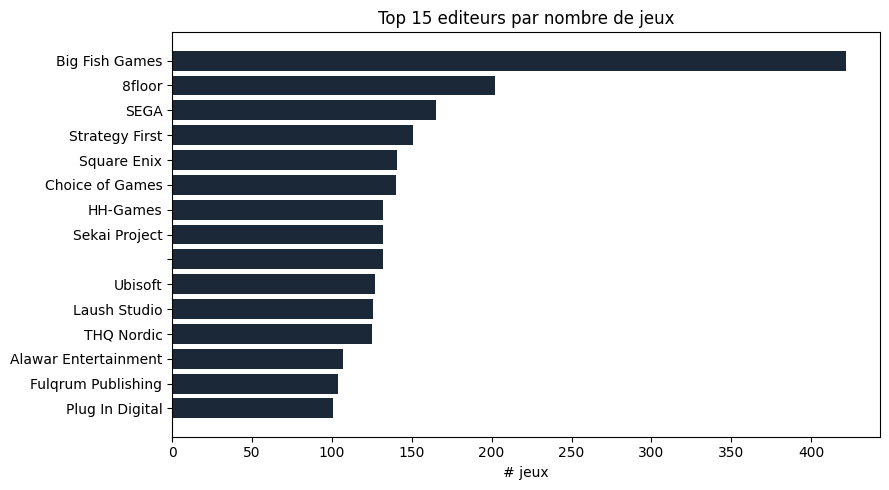

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\02_releases_by_year.png


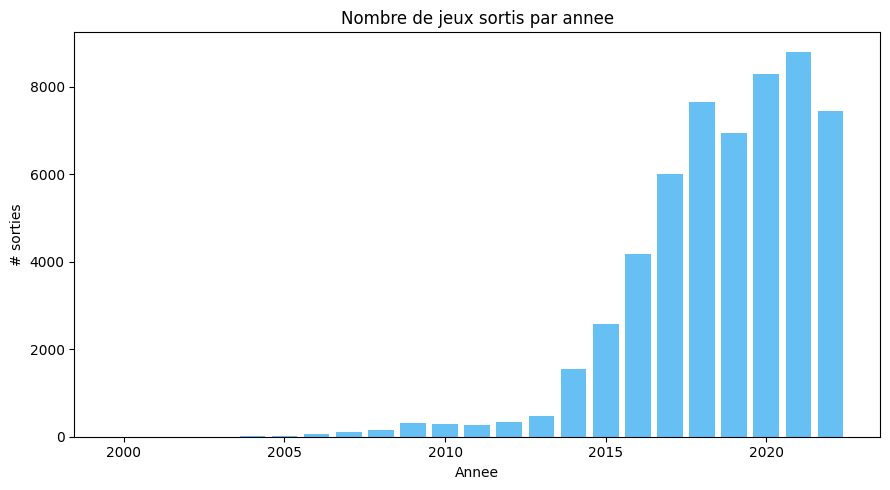

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\03_top_genres.png


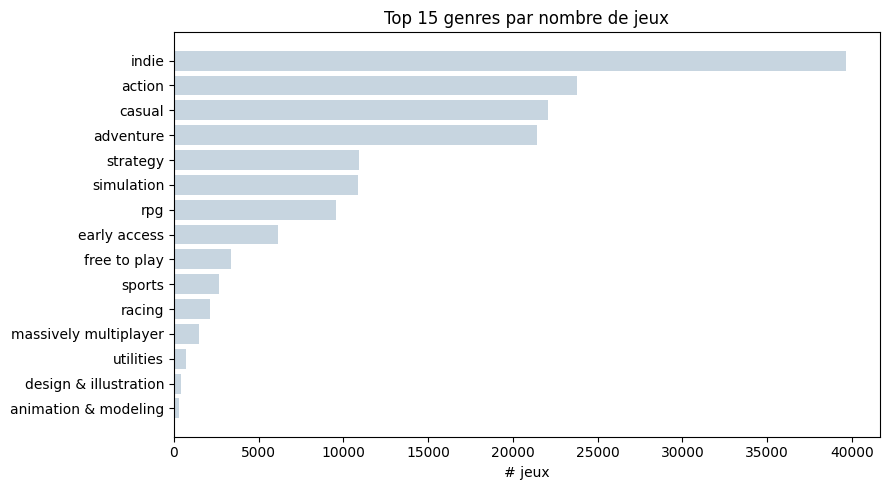

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\04_price_distribution.png


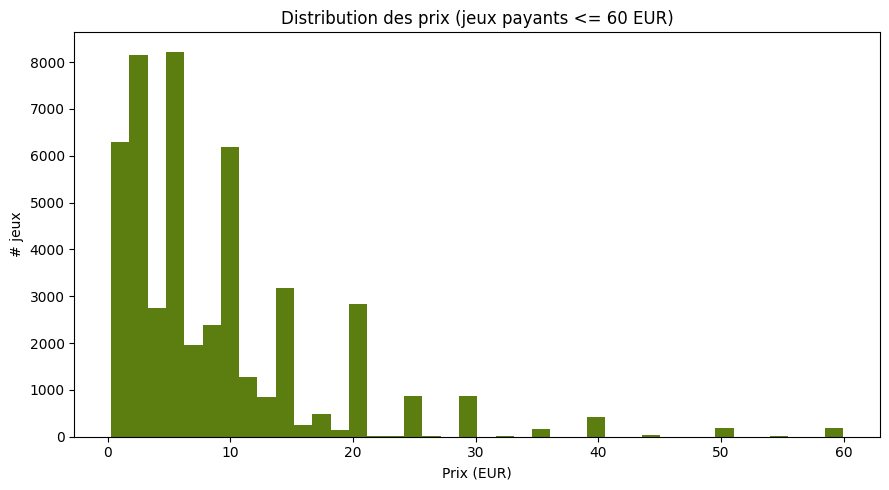

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\05_platform_share.png


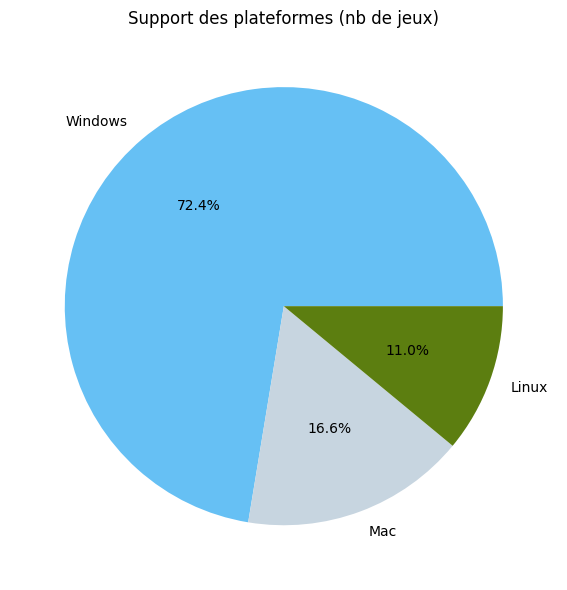

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\06_success_by_price.png


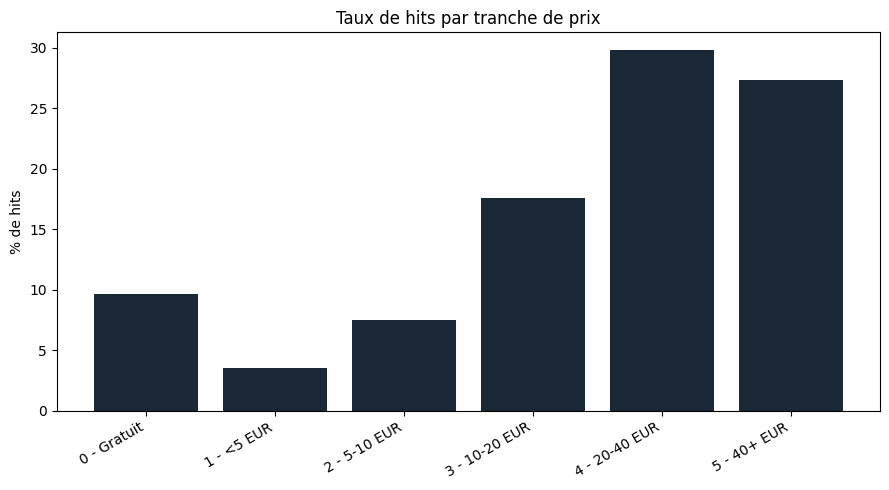

saved C:/Users/aymer/Desktop/Jedha certification/Jedha/Bloc_2_Steam/assets\07_success_by_platforms.png


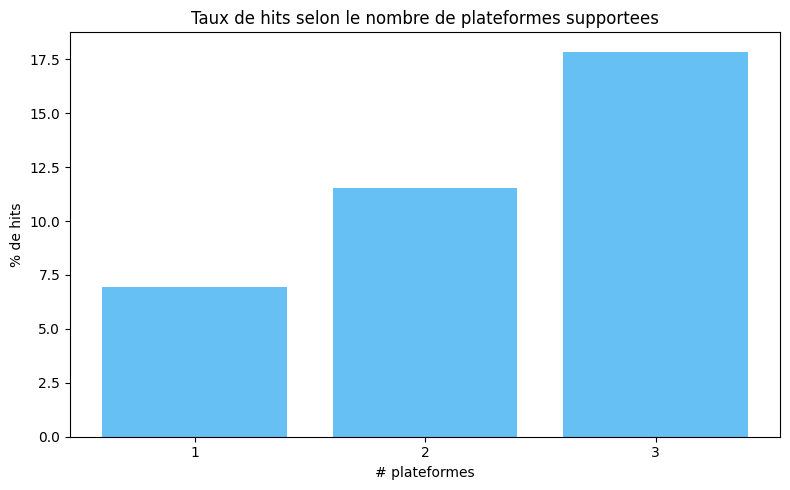

Exports termines.


In [12]:
import matplotlib.pyplot as plt

ASSETS = os.environ.get("STEAM_ASSETS", "../assets")
os.makedirs(ASSETS, exist_ok=True)

def savefig(fig, fname):
    path = os.path.join(ASSETS, fname)
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches="tight")
    print("saved", path)
    display(fig)   # embarque aussi l'image dans le notebook
    plt.close(fig)

# 1. Top 15 editeurs
pdf = publisher_most_games.limit(15).toPandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(pdf["publisher"][::-1], pdf["nb_games"][::-1], color="#1b2838")
ax.set_title("Top 15 editeurs par nombre de jeux"); ax.set_xlabel("# jeux")
savefig(fig, "01_top_publishers.png")

# 2. Sorties par annee
pdf = releases_by_year.toPandas()
pdf = pdf[(pdf["release_year"] >= 2000) & (pdf["release_year"] <= 2024)]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pdf["release_year"], pdf["nb_releases"], color="#66c0f4")
ax.set_title("Nombre de jeux sortis par annee"); ax.set_xlabel("Annee"); ax.set_ylabel("# sorties")
savefig(fig, "02_releases_by_year.png")

# 3. Top 15 genres
pdf = top_genres.limit(15).toPandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(pdf["genre"][::-1], pdf["nb_games"][::-1], color="#c7d5e0")
ax.set_title("Top 15 genres par nombre de jeux"); ax.set_xlabel("# jeux")
savefig(fig, "03_top_genres.png")

# 4. Distribution des prix payants
pdf = games.filter((F.col("price_eur") > 0) & (F.col("price_eur") <= 60)).select("price_eur").toPandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pdf["price_eur"], bins=40, color="#5c7e10")
ax.set_title("Distribution des prix (jeux payants <= 60 EUR)"); ax.set_xlabel("Prix (EUR)"); ax.set_ylabel("# jeux")
savefig(fig, "04_price_distribution.png")

# 5. Part des plateformes
pdf = platform_share.toPandas().T.reset_index()
pdf.columns = ["platform", "count"]
pdf["platform"] = ["Windows", "Mac", "Linux"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(pdf["count"], labels=pdf["platform"], autopct="%1.1f%%",
       colors=["#66c0f4", "#c7d5e0", "#5c7e10"])
ax.set_title("Support des plateformes (nb de jeux)")
savefig(fig, "05_platform_share.png")

# 6. Succes par bucket de prix
pdf = price_bucket_vs_success.toPandas().sort_values("price_bucket")
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pdf["price_bucket"], pdf["success_rate"] * 100, color="#1b2838")
ax.set_title("Taux de hits par tranche de prix"); ax.set_ylabel("% de hits")
plt.xticks(rotation=30, ha="right")
savefig(fig, "06_success_by_price.png")

# 7. Succes par nb de plateformes
pdf = platforms_vs_success.toPandas()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pdf["nb_platforms"].astype(str), pdf["success_rate"] * 100, color="#66c0f4")
ax.set_title("Taux de hits selon le nombre de plateformes supportees")
ax.set_xlabel("# plateformes"); ax.set_ylabel("% de hits")
savefig(fig, "07_success_by_platforms.png")

print("Exports termines.")